# LIBRARY

In [1]:
from collections import Counter

from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_score, recall_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.metrics import (
    roc_auc_score
)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import roc_curve, auc
from imblearn.pipeline import Pipeline          
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
def print_dist(y, label, binary=False):
    unique, counts = np.unique(y, return_counts=True)
    proportions    = counts / counts.sum()
    prefix         = 'binary=' if binary else 'sii='
    df = pd.DataFrame({
        'Class':      [f'{prefix}{u}' for u in unique],
        'Count':      counts,
        'Proportion': proportions.round(4),
        'Percentage': (proportions * 100).round(2)
    })
    print(f"\n{'='*60}")
    print(f"  SET: {label}")
    print(df.to_string(index=False))

# READ DATAFRAME

In [3]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [4]:
df

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
0,0,5,0,16.877316,46.000,50.800000,82.152821,4.611111,17.883041,6.500000,2.0,2.668550,1492.000000,41.586230,9.213770,1.0,19.541300,32.690900,2.0
1,1,9,0,14.035590,48.000,46.000000,90.666667,8.000000,18.204545,11.000000,2.0,2.579490,1498.650000,42.029150,3.970850,1.0,15.410700,27.055200,0.0
2,2,10,1,16.648696,56.500,75.600000,82.333333,27.000000,12.450000,10.000000,3.0,3.389932,1796.890000,59.788250,15.811750,2.0,25.634700,42.380000,0.0
3,3,9,0,18.292347,56.000,81.600000,79.000000,23.000000,18.204545,7.000000,3.0,3.841910,1923.440000,62.775700,18.824300,2.0,26.479800,45.996600,1.0
4,4,18,1,17.937682,54.626,76.139461,90.152104,12.000000,26.463732,8.003205,3.0,12.054014,2652.510000,60.327711,15.811750,2.0,29.912400,42.380000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8391,8455,7,1,16.130585,46.070,48.700252,81.861037,6.500000,18.075000,7.000000,1.0,2.625946,1490.847845,45.526276,3.173977,1.0,18.024600,31.583004,0.0
8392,8456,10,1,17.300000,56.130,77.531978,79.833333,8.500000,13.575000,5.000000,3.0,4.987853,1678.330810,69.880763,7.651215,1.0,22.983200,36.475662,1.0
8393,8457,10,1,40.937571,49.560,143.030726,82.166667,21.500000,16.840263,9.500000,4.0,3.990512,1547.346725,107.979706,35.051020,2.0,31.594712,35.106855,0.0
8394,8458,15,1,22.500000,63.790,130.236404,88.395702,10.000000,26.417470,10.500000,2.0,4.967841,1674.735823,103.517750,26.718654,2.0,46.467581,57.530686,2.0


In [5]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8396, 17)
y shape : (8396,)
Classes : [0. 1. 2. 3.]
Class counts : {0.0: 5801, 1.0: 1570, 2.0: 941, 3.0: 84}


# Data Preparation

In [6]:
X.shape

(8396, 17)

In [7]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5801, 1570,  941,   84]))

In [8]:
Counter(y)

Counter({2.0: 941, 0.0: 5801, 1.0: 1570, 3.0: 84})

In [9]:
ctr = Counter(y)
ctr

Counter({2.0: 941, 0.0: 5801, 1.0: 1570, 3.0: 84})

## Data Partitioning

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [11]:
X_train.shape

(5877, 17)

In [12]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0., 1., 2., 3.]), array([4060, 1099,  659,   59])),
 (array([0., 1., 2., 3.]), array([1741,  471,  282,   25])))

In [13]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.6908286540752084

In [14]:

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [15]:

print(f"Train samples : {len(y_train)}")
print(f"Test samples  : {len(y_test)}")

Train samples : 5877
Test samples  : 2519


# CASCADE

## model

In [16]:
param_list = {
    'C':            [0.001,0.01,0.1, 1, 10, 100],
    'penalty':      ['l1', 'l2', 'elasticnet'],
    'solver':       ['saga'],
    'l1_ratio':     np.linspace(0, 1, 10).tolist(),
    'class_weight': ['balanced', None]
}

In [17]:
def train_one_step(X_train, y_binary, X_test, y_test_binary, step_name,
                   n_iter=50, n_splits=5, random_state=0):

    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

    random_search = RandomizedSearchCV(
        LogisticRegression(random_state=random_state),
        param_distributions=param_list,       # ← list of dicts (valid combos)
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring='f1_macro',
        n_jobs=-1,
        refit=True,
        n_iter=n_iter,
        random_state=random_state,
        error_score='raise',                  # ← surface errors immediately
    )
    random_search.fit(X_train, y_binary)

    best_model = random_search.best_estimator_
    best_model.fit(X_train, y_binary)

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")

    # ── Predictions ───────────────────────────────────────────────────────────
    y_pred_binary = best_model.predict(X_test)
    y_proba       = best_model.predict_proba(X_test)[:, 1]  # ← P(positive class)
                                                             #   only 2 columns in binary

    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    print(f"  Test F1     : {test_f1:.4f}")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm   = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f'not {step_name}', step_name]
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.tight_layout()
    plt.show()

    # ── ROC curve ─────────────────────────────────────────────────────────────

    fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
    roc_auc     = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='#7F77DD', linewidth=2,
             label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {step_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # ── Reports ───────────────────────────────────────────────────────────────
    print(classification_report(y_test_binary, y_pred_binary,
                                target_names=[f'not {step_name}', step_name]))

    print(f"\n  Confusion Matrix breakdown:")
    print(f"    TN (correct negatives) : {cm[0,0]}")
    print(f"    FP (false positives)   : {cm[0,1]}")
    print(f"    FN (false negatives)   : {cm[1,0]}")
    print(f"    TP (correct positives) : {cm[1,1]}")
    print(f"    AUC                    : {roc_auc:.4f}")

    return best_model

## split 

In [18]:
# 
step_results = {}   
y_pred_final = np.full(len(X_test), -1)
original_idx = np.arange(len(X_test))

# Working copies that shrink at each cascade step
X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2. 3.]
Train samples  : 5877
Test samples   : 2519


In [19]:
print_dist(y_tr, 'TRAIN')
print_dist(y_te, 'TEST')


  SET: TRAIN
  Class  Count  Proportion  Percentage
sii=0.0   4060      0.6908       69.08
sii=1.0   1099      0.1870       18.70
sii=2.0    659      0.1121       11.21
sii=3.0     59      0.0100        1.00

  SET: TEST
  Class  Count  Proportion  Percentage
sii=0.0   1741      0.6911       69.11
sii=1.0    471      0.1870       18.70
sii=2.0    282      0.1119       11.19
sii=3.0     25      0.0099        0.99


### class 0

In [20]:
# ── STEP 1: sii=0 vs [1, 2, 3] ───────────────────────────────────────────
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [21]:
print_dist(y_binary_tr, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   1817      0.3092       30.92
binary=1   4060      0.6908       69.08

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    778      0.3089       30.89
binary=1   1741      0.6911       69.11


In [22]:

# over_dic={0:3500}
# #under_dic={0:3000}
# over = SMOTE(random_state=42, sampling_strategy=over_dic)
# #under = TomekLinks(sampling_strategy='majority')
# X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
# print('Resampled dataset shape %s' % Counter(y_res))


  STEP: sii=0
  Training samples : 5877
  Positive class   : 4060 samples
  Negative class   : 1817 samples


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (


  Best params : {'solver': 'saga', 'penalty': 'l1', 'l1_ratio': 0.0, 'class_weight': 'balanced', 'C': 0.01}
  Best CV F1  : 0.6142
  Test F1     : 0.6474


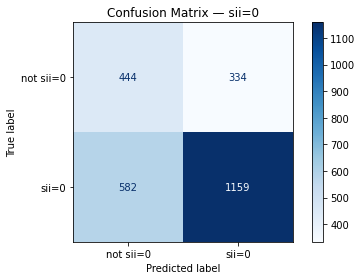

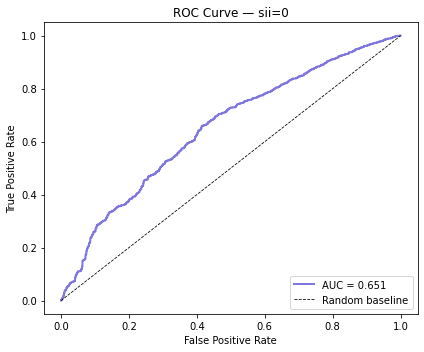

              precision    recall  f1-score   support

   not sii=0       0.43      0.57      0.49       778
       sii=0       0.78      0.67      0.72      1741

    accuracy                           0.64      2519
   macro avg       0.60      0.62      0.60      2519
weighted avg       0.67      0.64      0.65      2519


  Confusion Matrix breakdown:
    TN (correct negatives) : 444
    FP (false positives)   : 334
    FN (false negatives)   : 582
    TP (correct positives) : 1159
    AUC                    : 0.6510


In [23]:
models[0] = train_one_step(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=0')

In [24]:
# samples predicted as sii=0 → assign 0 to their original position
y_pred_te   = models[0].predict(X_te)

#----------------------------------
step_results[0] = {
    'step_name':    'sii=0 vs [1,2,3]',
    'y_true_bin':   y_binary_te.copy(),      # verdadero binario
    'y_pred_bin':   y_pred_te.copy(),        # predicho binario
    'y_true_orig':  y_te.copy(),             # verdadero multiclass en este paso
    'original_idx': original_idx.copy(),     # índices originales
}

y_pred_final[original_idx[y_pred_te == 1]] = 0

print(f"\n  Assigned as sii=0 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=0 : 1493 samples


### class 1 

In [25]:
# TRAIN → remove all true sii=0 
mask_tr      = y_tr != 0
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink index tracker too

In [26]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 1')
print_dist(y_te, 'TEST  after step 1')

  Remaining train : 1817
  Remaining test  : 1360

  SET: TRAIN after step 1
  Class  Count  Proportion  Percentage
sii=1.0   1099      0.6048       60.48
sii=2.0    659      0.3627       36.27
sii=3.0     59      0.0325        3.25

  SET: TEST  after step 1
  Class  Count  Proportion  Percentage
sii=0.0    582      0.4279       42.79
sii=1.0    471      0.3463       34.63
sii=2.0    282      0.2074       20.74
sii=3.0     25      0.0184        1.84


In [27]:
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)

In [28]:
print_dist(y_binary_tr, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    718      0.3952       39.52
binary=1   1099      0.6048       60.48

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    889      0.6537       65.37
binary=1    471      0.3463       34.63



  STEP: sii=1
  Training samples : 1817
  Positive class   : 1099 samples
  Negative class   : 718 samples


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used


  Best params : {'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.4444444444444444, 'class_weight': 'balanced', 'C': 0.01}
  Best CV F1  : 0.5795
  Test F1     : 0.6495


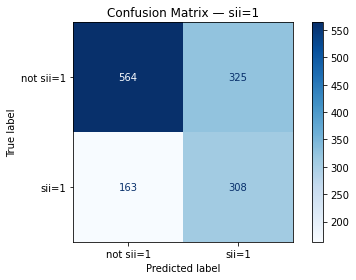

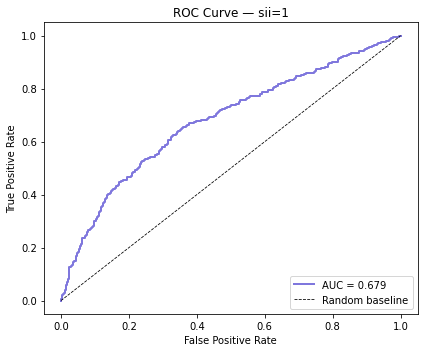

              precision    recall  f1-score   support

   not sii=1       0.78      0.63      0.70       889
       sii=1       0.49      0.65      0.56       471

    accuracy                           0.64      1360
   macro avg       0.63      0.64      0.63      1360
weighted avg       0.68      0.64      0.65      1360


  Confusion Matrix breakdown:
    TN (correct negatives) : 564
    FP (false positives)   : 325
    FN (false negatives)   : 163
    TP (correct positives) : 308
    AUC                    : 0.6788


In [29]:
models[1] = train_one_step(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=1')

In [30]:
y_pred_te   = models[1].predict(X_te)

step_results[1] = {
    'step_name':    'sii=1 vs [2,3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 1

print(f"\n  Assigned as sii=1 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=1 : 633 samples


### class 2

In [31]:
# TRAIN → remove all true sii=1
mask_tr      = y_tr != 1
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES 
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

In [32]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 2')
print_dist(y_te, 'TEST  after step 2')

  Remaining train : 718
  Remaining test  : 1052

  SET: TRAIN after step 2
  Class  Count  Proportion  Percentage
sii=2.0    659      0.9178       91.78
sii=3.0     59      0.0822        8.22

  SET: TEST  after step 2
  Class  Count  Proportion  Percentage
sii=0.0    582      0.5532       55.32
sii=1.0    163      0.1549       15.49
sii=2.0    282      0.2681       26.81
sii=3.0     25      0.0238        2.38


In [33]:
y_binary_tr = (y_tr == 2).astype(int)
y_binary_te = (y_te == 2).astype(int)

In [34]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0     59      0.0822        8.22
binary=1    659      0.9178       91.78

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    770      0.7319       73.19
binary=1    282      0.2681       26.81


In [35]:

"""over_dic={0:500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_tr, y_binary_tr = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_binary_tr))"""


"over_dic={0:500}\n#under_dic={0:3000}\nover = SMOTE(random_state=42, sampling_strategy=over_dic)\n#under = TomekLinks(sampling_strategy='majority')\nX_tr, y_binary_tr = over.fit_resample(X_tr, y_binary_tr)\nprint('Resampled dataset shape %s' % Counter(y_binary_tr))"

In [36]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0     59      0.0822        8.22
binary=1    659      0.9178       91.78

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    770      0.7319       73.19
binary=1    282      0.2681       26.81



  STEP: sii=2
  Training samples : 718
  Positive class   : 659 samples
  Negative class   : 59 samples


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used


  Best params : {'solver': 'saga', 'penalty': 'l2', 'l1_ratio': 0.5555555555555556, 'class_weight': 'balanced', 'C': 0.01}
  Best CV F1  : 0.4813
  Test F1     : 0.4877


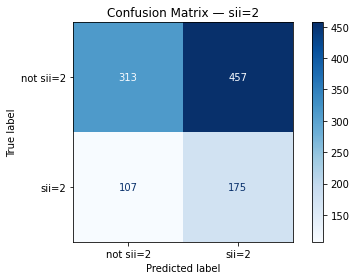

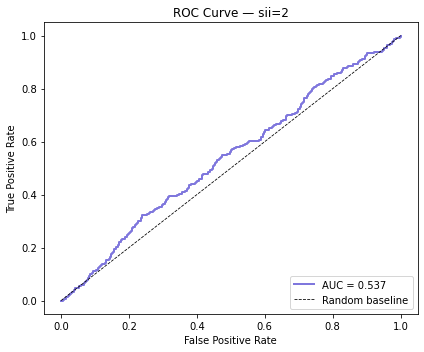

              precision    recall  f1-score   support

   not sii=2       0.75      0.41      0.53       770
       sii=2       0.28      0.62      0.38       282

    accuracy                           0.46      1052
   macro avg       0.51      0.51      0.45      1052
weighted avg       0.62      0.46      0.49      1052


  Confusion Matrix breakdown:
    TN (correct negatives) : 313
    FP (false positives)   : 457
    FN (false negatives)   : 107
    TP (correct positives) : 175
    AUC                    : 0.5371


In [37]:
models[2] = train_one_step(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=2')

In [38]:
# ── Assign predictions for step 3 ────────────────────────────────────────────
y_pred_te   = models[2].predict(X_te)

step_results[2] = {
    'step_name':    'sii=2 vs [3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 2

print(f"\n  Assigned as sii=2 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=2 : 632 samples


### class 3 

In [39]:
# ── Filter for next step ──────────────────────────────────────────────────────
mask_tr      = y_tr != 2
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")

  Remaining train : 59
  Remaining test  : 877


In [40]:
y_pred_final[original_idx] = 3
step_results[3] = {
    'step_name':    'sii=3 (remaining)',
    'y_true_bin':   (y_te == 3).astype(int),
    'y_pred_bin':   np.ones(len(y_te), dtype=int),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

print(f"\n  Assigned as sii=3 : {len(original_idx)} samples (all remaining)")


  Assigned as sii=3 : 877 samples (all remaining)


# RESULTS

In [41]:
# ══════════════════════════════════════════════════════════════════════════════
# REPORTE COMBINADO
# ══════════════════════════════════════════════════════════════════════════════


print("\n" + "="*75)
print("  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS")
print("="*75)

rows = []
for step, res in step_results.items():
    yt = res['y_true_bin']
    yp = res['y_pred_bin']

    # métricas binarias reales de cada paso
    prec   = precision_score(yt, yp, zero_division=0)
    rec    = recall_score(yt, yp, zero_division=0)
    f1     = f1_score(yt, yp, zero_division=0)
    n      = len(yt)
    n_pos  = yt.sum()
    tp     = ((yp == 1) & (yt == 1)).sum()
    fp     = ((yp == 1) & (yt == 0)).sum()
    fn     = ((yp == 0) & (yt == 1)).sum()

    rows.append({
        'Step':         res['step_name'],
        'N samples':    n,
        'N positive':   n_pos,
        'TP':           tp,
        'FP':           fp,
        'FN':           fn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
    })

report_df = pd.DataFrame(rows)
print(report_df.to_string(index=False))


  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS
             Step  N samples  N positive   TP  FP  FN  Precision  Recall     F1
 sii=0 vs [1,2,3]       2519        1741 1159 334 582     0.7763  0.6657 0.7168
   sii=1 vs [2,3]       1360         471  308 325 163     0.4866  0.6539 0.5580
     sii=2 vs [3]       1052         282  175 457 107     0.2769  0.6206 0.3829
sii=3 (remaining)        877          25   25 852   0     0.0285  1.0000 0.0554


In [42]:
# ── Multiclass final ──────────────────────────────────────────────────────────
print("\n" + "="*75)
print("  FINAL MULTICLASS REPORT (y_test vs y_pred_final)")
print("="*75)
print(classification_report(
    y_test, y_pred_final,
    target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']
))


  FINAL MULTICLASS REPORT (y_test vs y_pred_final)
              precision    recall  f1-score   support

       sii=0       1.00      0.67      0.80      1741
       sii=1       1.00      0.65      0.79       471
       sii=2       1.00      0.62      0.77       282
       sii=3       0.03      1.00      0.06        25

    accuracy                           0.66      2519
   macro avg       0.76      0.74      0.60      2519
weighted avg       0.99      0.66      0.79      2519



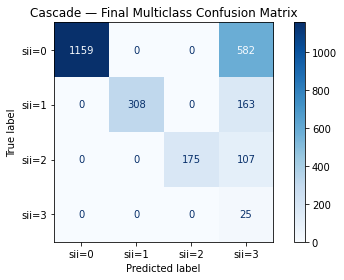

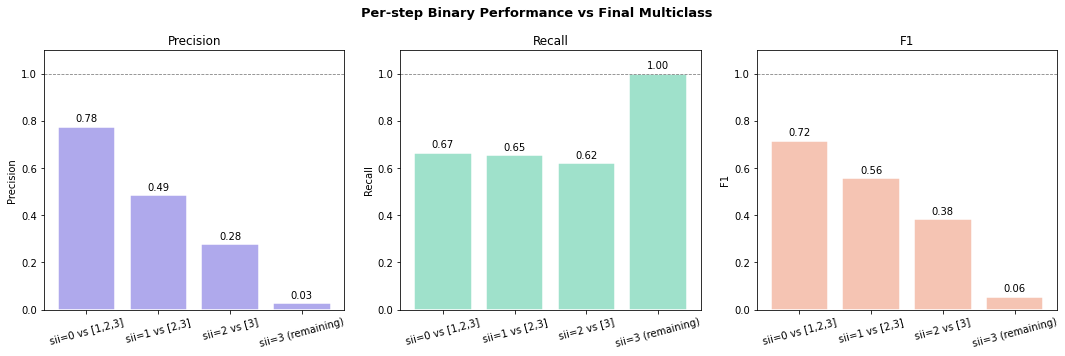

In [43]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sii=0', 'sii=1', 'sii=2', 'sii=3']
)
disp.plot(cmap='Blues')
plt.title('Cascade — Final Multiclass Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'F1']
colors    = ['#AFA9EC', '#9FE1CB', '#F5C4B3']

for ax, metric, color in zip(axes, metrics, colors):
    steps  = [r['Step'] for r in rows]
    values = [r[metric] for r in rows]
    bars   = ax.bar(steps, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Per-step Binary Performance vs Final Multiclass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
# ── Per class summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  PREDICTIONS SUMMARY")
print(f"{'='*60}")
for cls in [0, 1, 2, 3]:
    true_count = (y_test == cls).sum()
    pred_count = (y_pred_final == cls).sum()
    print(f"  sii={cls} → true: {true_count:<6} predicted: {pred_count}")


  PREDICTIONS SUMMARY
  sii=0 → true: 1741   predicted: 1159
  sii=1 → true: 471    predicted: 308
  sii=2 → true: 282    predicted: 175
  sii=3 → true: 25     predicted: 877


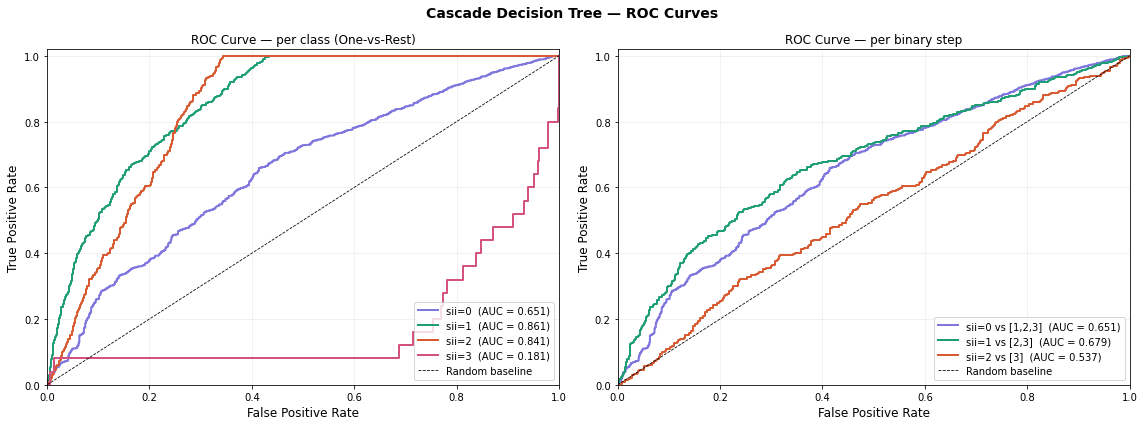


  AUC SUMMARY
  sii=0    → AUC = 0.6510
  sii=1    → AUC = 0.8606
  sii=2    → AUC = 0.8407
  sii=3    → AUC = 0.1809

  Macro AUC    : 0.6333
  Weighted AUC : 0.7067


In [45]:


# ── 1. Collect probabilities from each step ───────────────────────────────────
# Each model gives P(class=X) for the samples it saw
# We need to reconstruct full probability matrix (n_test, 4)

n_test     = len(X_test)
proba_full = np.zeros((n_test, 4))   # one column per class

for step, res in step_results.items():
    idx    = res['original_idx']          # which original test samples this step saw
    model  = models.get(step)

    if model is not None:
        proba_step         = model.predict_proba(X_test[idx])   # shape (n_step, 2)
        proba_full[idx, step] = proba_step[:, 1]                # P(positive) for this class
    else:
        # last class — use survival probability (1 - sum of previous)
        proba_full[idx, step] = 1 - proba_full[idx, :step].sum(axis=1)

# ── 2. Binarize y_test for multiclass ROC ────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # shape (n_test, 4)

# ── 3. Compute ROC per class ──────────────────────────────────────────────────
colors     = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E']
step_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

for i in range(4):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_dict[i]                  = auc(fpr_dict[i], tpr_dict[i])

# ── 4. Plot — two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1 — individual ROC per class ───────────────────────────────────────
ax = axes[0]
for i in range(4):
    ax.plot(fpr_dict[i], tpr_dict[i],
            color=colors[i],
            linewidth=2,
            label=f"{step_names[i]}  (AUC = {auc_dict[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per class (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

# ── Panel 2 — step by step binary ROC ────────────────────────────────────────
ax = axes[1]
for step, res in step_results.items():
    model = models.get(step)
    if model is None:
        continue                              # skip last class (no model)

    idx        = res['original_idx']
    y_true_bin = res['y_true_bin']
    y_proba    = model.predict_proba(X_test[idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=colors[step],
            linewidth=2,
            label=f"{step_results[step]['step_name']}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per binary step', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

plt.suptitle('Cascade Decision Tree — ROC Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Print AUC summary ──────────────────────────────────────────────────────
print("\n" + "="*45)
print("  AUC SUMMARY")
print("="*45)
for i in range(4):
    print(f"  {step_names[i]:<8} → AUC = {auc_dict[i]:.4f}")


macro    = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='macro')
weighted = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='weighted')
print(f"\n  Macro AUC    : {macro:.4f}")
print(f"  Weighted AUC : {weighted:.4f}")
print("="*45)